# Simple Neural Network from scratch in MNIST dataset

A fully parametric multilayer perceptron (MLP) implemented from scratch using only NumPy — no high-level deep learning frameworks. Built to show fundamental understanding of the theory behind Neural Networks: forward propagation, backpropagation, and gradient-based optimization.

## 1. Dataset Handling
Import, format, explore and visualize the dataset using keras for simplicity. The datasets that will be used are 
- [MNIST (digits)](https://github.com/sunsided/mnist): The widely known dataset with handwritten numbers (0-9) that is commonly used in classification applications. It contains a training set of `60.000` examples and a testing set of `10.000` examples. Each example is a `28x28` grayscale image of a character from 0 to 9
- [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist): A more challenging version of the MNIST dataset intended as a replacement to the simple version of handwritten characters. It follows the same format but instead of numbers it contains classes corresponding to fashion items (shoe, dress, coat etc.)

In [1]:
# Initial Imports
import numpy as np
import matplotlib.pyplot as plt

### 1.1 Dataset Import and Data Formating


In [ ]:
from keras.datasets import fashion_mnist as mnist
from sklearn.model_selection import train_test_split

# Load dataset
(x_2d_train, y_train), (x_2d_test, y_test) = mnist.load_data()

# Flatten the 2D images to 1D vectors
x_train = x_2d_train.reshape(x_2d_train.shape[0], -1)
x_test = x_2d_test.reshape(x_2d_test.shape[0], -1)

# Split test data to test and validation data respectively
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=42)


# Normalize input values
print('\nNormalize input values:')
def normalize(numbers, new_min=0.0, new_max=1.0):
    curr_min = float(numbers.min())
    curr_max = float(numbers.max())

    normalized = (numbers-curr_min)/(curr_max-curr_min)

    return normalized

print('Min value of input: ',x_train.min())
print('Max value of input: ',x_train.max())
x_train_normalized = normalize(x_train)
x_test_normalized = normalize(x_test)
x_val_normalized = normalize(x_val)
print('Min value of normalized input: ',x_train_normalized.min())
print('Max value of normalized input: ',x_train_normalized.max())

# Convert target data to one hot encoding vectors
def toonehot(input):
    temp = np.zeros((input.shape[0], 10))
    for i, row in enumerate(input):
        temp[i][input[i]] = 1

    return temp

y_train_one_hot = toonehot(y_train)
y_val_one_hot = toonehot(y_val)
y_test_one_hot = toonehot(y_test)


Normalize input values:
Min value of input:  0
Max value of input:  255
Min value of normalized input:  0.0
Max value of normalized input:  1.0


### 1.2 Data Exploration

Percentage of train data: 0.86
Percentage of val data: 0.07
Percentage of test data: 0.07


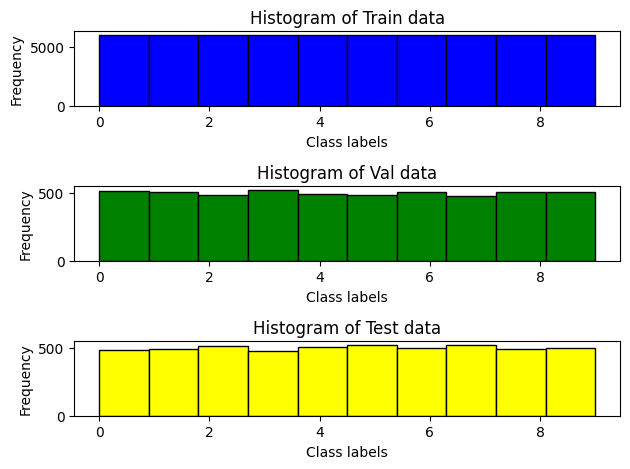


Shapes of input and target data:
X_train: (60000, 784)
Y_train: (60000, 10)
X_val: (5000, 784)
Y_val: (5000, 10)
X_test: (5000, 784)
Y_test: (5000, 10)


In [5]:
percentage_train = len(y_train) / float(len(y_train) + len(y_val) + len(y_test))
percentage_val = len(y_val) / float(len(y_train) + len(y_val) + len(y_test))
percentage_test = len(y_test) / float(len(y_train) + len(y_val) + len(y_test))

print(f"Percentage of train data: {percentage_train:.2f}")
print(f"Percentage of val data: {percentage_val:.2f}")
print(f"Percentage of test data: {percentage_test:.2f}")


# Histogram of number distributions on each data subdivision
fig, ax = plt.subplots(3,1)

ax[0].hist(y_train, color='Blue', edgecolor='black')
ax[0].set_title("Histogram of Train data")
ax[0].set_ylabel("Frequency")
ax[0].set_xlabel("Class labels")


ax[1].hist(y_val, color='Green', edgecolor='black')
ax[1].set_title("Histogram of Val data")
ax[1].set_ylabel("Frequency")
ax[1].set_xlabel("Class labels")

ax[2].hist(y_test, color='Yellow', edgecolor='black')
ax[2].set_title("Histogram of Test data")
ax[2].set_ylabel("Frequency")
ax[2].set_xlabel("Class labels")

plt.tight_layout()
plt.show()


print('\nShapes of input and target data:')

print("X_train:", x_train_normalized.shape)
print("Y_train:", y_train_one_hot.shape)
print("X_val:", x_val_normalized.shape)
print("Y_val:", y_val_one_hot.shape)
print("X_test:", x_test_normalized.shape)
print("Y_test:", y_test_one_hot.shape)

### 1.2 Dataset Visualization

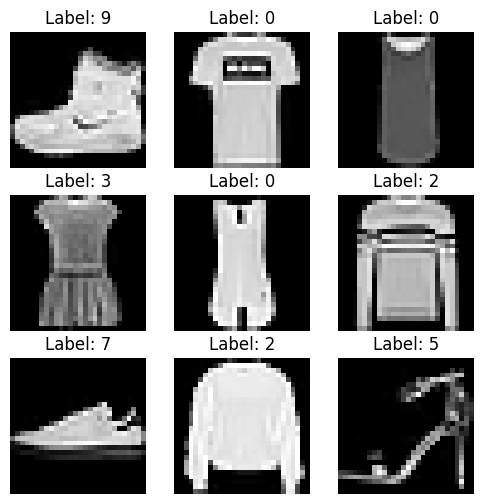

In [12]:
# Visualize some of the training data

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_2d_train[i], cmap=plt.get_cmap('gray'))
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')


### 2. Class init

In [18]:
class Neural_Net:
    def __init__(self, layer_sizes, activations, epochs=10, batch_size=32, learning_rate=0.01):
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate

        self.layer_sizes = layer_sizes
        self.activations = activations

        self.layers = []
        # Build the layers of the neural network
        for i in range(len(layer_sizes) - 1):
            is_output = (i == len(layer_sizes) - 2)

            self.layers.append(
                Layer(
                    layer_sizes[i], 
                    layer_sizes[i+1], 
                    activations[i],
                    output_layer=is_output
                )
            )

        for i in range(len(self.layers) - 1):
            self.layers[i].next_layer = self.layers[i+1]

        self.loss = []
        self.accuracies = []
        self.loss_per_epoch = []



    def fit(self, x_train, y_train, x_val=None, y_val=None, Verbose=True):
        L = 0
        for epoch in range(self.epochs):
            if Verbose:
                print(f"Epoch {epoch+1}/{self.epochs}")

            perm = np.random.permutation(len(x_train))
            x_train_shuffled = x_train[perm]
            y_train_shuffled = y_train[perm]

            # Run across the entire training data in batches
            for j in range(x_train_shuffled.shape[0] ):
                x = x_train_shuffled[j]
                targets = y_train_shuffled[j]

                outputs = self._forward(x)
                self._backward(targets)

                # Update weights (once every mini batch)
                L += (1/self.batch_size) * cross_entropy_loss(outputs, targets)
                if (j+1)%self.batch_size == 0:
                    self.loss.append(L)

                    L = 0

                    self._update_weights()

            if x_val is not None and y_val is not None:
                accuracy = self.evaluate(x_val, y_val)
                self.accuracies.append(accuracy)
                self.loss_per_epoch.append(self.loss[-1])

                if Verbose:
                    print(f"Loss for epoch {epoch+1}: {self.loss[-1]:.4f}")
                    print(f"Validation accuracy for epoch {epoch+1}: {accuracy:.4f}")

        return self.loss_per_epoch, self.accuracies

    def predict(self, x):
        outputs = self._forward(x)
        return np.argmax(outputs)

    def evaluate(self, x_val, y_val):
        correct_predictions = sum( self.predict(x_val[i]) == np.argmax(y_val[i]) for i in range(len(x_val)))
        accuracy = correct_predictions / len(x_val)
        return accuracy

    def _forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def _backward(self, targets):
        for layer in reversed(self.layers):
            layer.backward(mini_batch=self.batch_size, targets=targets)
            

    def _update_weights(self):
        for layer in self.layers:
            layer.update_weights(self.learning_rate)

In [19]:
class relu:
    def forward(self, z):
        return np.maximum(0,z)
    
    def derivative(self, output):
        return 1 * (output>0)
    
class leaky_relu:
    def __init__(self, alpha=0.01):
        self.alpha = alpha
        
    def forward(self, z):
        return np.where(z > 0, z, self.alpha * z)
    
    def derivative(self, output):
        return np.where(output > 0, 1, self.alpha)
    

class softmax:
    def forward(self, z):
        z_shifted = z - max(z)
        exped = np.exp(z_shifted)
        return exped / np.sum(exped)
    
    def derivative(self, output):
        pass

def cross_entropy_loss(predictions, targets):
    loss = -np.sum(targets * np.log(predictions + 1e-12) )
    return loss

In [26]:
class Layer:
    def __init__(self, input_size, output_size, activation_func=relu(), output_layer=False):
        self.input_size = input_size
        self.output_size = output_size
        # self.weights = np.random.rand(output_size, input_size) * 0.001
        self.weights = np.random.randn(output_size, input_size) * np.sqrt(2 / input_size)
        self.new_weights = None # maybe not necessary
        self.biases = np.zeros(output_size) #np.random.rand(output_size)
        self.new_biases = None # maybe not necessary

        self.inputs = None

        self.z = None
        self.a = None

        self.activation_func = activation_func

        self.delta = None
        self.grad_w = 0
        self.grad_b = 0

        self.output_layer = output_layer

        self.next_layer = None

    def forward(self, inputs):
        # z = W*x + b
        self.inputs = inputs
        self.z = np.dot(self.weights, self.inputs)
        self.z += self.biases
        
        # a = g(z)
        self.a = self.activation_func.forward(self.z)
        return self.a
    
    def backward(self, mini_batch=32, targets=None):
        
        # Calculate delta
        if self.output_layer:
            self.delta = self.a - targets
        else:
            next_w = self.next_layer.weights
            next_delta = self.next_layer.delta
            # (next weights (not updated) @ next delta) * self.activation_func.derivative()
            self.delta = np.dot(next_w.T, next_delta) * self.activation_func.derivative(self.z) 

        # Calculate gradients 
        self.grad_w += (1/mini_batch) * np.outer(self.delta, self.inputs)
        self.grad_b += (1/mini_batch) * self.delta

    def update_weights(self, learning_rate):
        # W' = W - η*ΔW
        # print('grad w:', self.grad_w.shape)
        # print('grad b:', self.grad_b.shape)
        self.weights -= learning_rate * self.grad_w
        self.biases -= learning_rate * self.grad_b

        self.grad_w = 0
        self.grad_b = 0
        
      
    

In [ ]:
model = Neural_Net(layer_sizes=[784, 256, 64, 10], activations=[leaky_relu(), leaky_relu(), softmax()], epochs=10, batch_size=64, learning_rate=0.005)

losses, accuracies = model.fit(x_train_normalized, y_train_one_hot, x_val=x_val_normalized, y_val=y_val_one_hot, Verbose=True)
losses, accuracies = [float(loss) for loss in losses], [float(acc) for acc in accuracies]

Epoch 1/10
Loss for epoch 1: 0.7401
Validation accuracy for epoch 1: 0.7576
Epoch 2/10
Loss for epoch 2: 0.6017
Validation accuracy for epoch 2: 0.7892
Epoch 3/10
Loss for epoch 3: 0.5343
Validation accuracy for epoch 3: 0.8122
Epoch 4/10
Loss for epoch 4: 0.3446
Validation accuracy for epoch 4: 0.8184
Epoch 5/10
Loss for epoch 5: 0.5156
Validation accuracy for epoch 5: 0.8268
Epoch 6/10
Loss for epoch 6: 0.4336
Validation accuracy for epoch 6: 0.8230
Epoch 7/10
Loss for epoch 7: 0.4236
Validation accuracy for epoch 7: 0.8310
Epoch 8/10
Loss for epoch 8: 0.3596
Validation accuracy for epoch 8: 0.8370
Epoch 9/10
Loss for epoch 9: 0.3931
Validation accuracy for epoch 9: 0.8420
Epoch 10/10
Loss for epoch 10: 0.3441
Validation accuracy for epoch 10: 0.8446


## 3.1 Testing the model in Test set

It's important to test model's performance in unseen data, this way we are unbiased.

In [ ]:
accuracy = float(model.evaluate(x_test_normalized, y_test_one_hot))

print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 84.62%


NameError: name 'fashion_model' is not defined

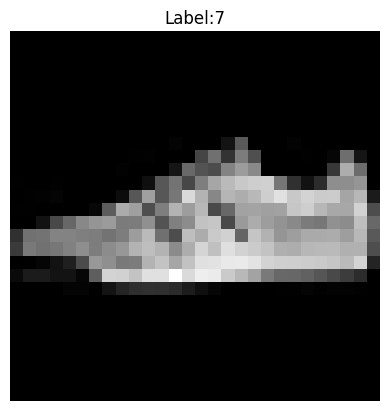

In [ ]:
random_index = np.random.randint(0, len(x_test_normalized))
random_image = x_test_normalized[random_index].reshape(28, 28)

fig, ax = plt.subplots()

label = y_test_one_hot[random_index].argmax()
ax.set_title(f"Label:{label}")
ax.imshow(random_image, cmap=plt.get_cmap('gray'))
ax.axis('off')

print(f"Predicted label: {model.predict(x_test_normalized[random_index])}")
print(f"True label: {y_test[random_index]}")
